# Basic Faraday Depth Synthesis

This notebook demonstrates the basic workflow of Faraday depth synthesis:
1. Simulating a Faraday-thin source
2. Computing the dirty Faraday depth spectrum
3. Visualizing the results

This is the foundation for all Faraday depth analysis.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from csromer.simulation import FaradayThinSource
from csromer.pipelines.simulation import run_simulation, SimulateStep, ApplyNoiseStep
from csromer.pipelines.reconstruction import build_parameter, build_measurement_operator
from csromer.utils.array_utils import asnumpy

# Set up plotting
plt.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline

## 1. Simulate a Faraday-Thin Source

Create a point source at a specific Faraday depth.

In [12]:
# Frequency coverage (uniform spacing)
nu = np.linspace(1.0e9, 1.5e9, 128)  # 1.0 - 1.5 GHz, 128 channels

# Create a thin source at phi_gal = 50 rad/m² and run simulation pipeline (simulate + noise)
source = FaradayThinSource(
    nu=nu,
    s_nu=0.1,  # 0.1 Jy flux density
    phi_gal=50.0,  # 50 rad/m² Faraday depth
    spectral_idx=-0.7,  # Spectral index
)
run_simulation(source, [
    SimulateStep(),
    ApplyNoiseStep(0.01, random_state=np.random.RandomState(42)),
])

print(f"Source created:")
print(f"  Frequency range: {nu.min()/1e9:.2f} - {nu.max()/1e9:.2f} GHz")
print(f"  Number of channels: {len(nu)}")
print(f"  Faraday depth: {source.phi_gal:.2f} rad/m²")
print(f"  Flux density: {source.s_nu:.3f} Jy")

Source created:
  Frequency range: 1.00 - 1.50 GHz
  Number of channels: 128
  Faraday depth: 50.00 rad/m²
  Flux density: 0.100 Jy


## 2. Plot the Simulated Polarization Data

Visualize the complex polarization P(λ²) = Q + iU.

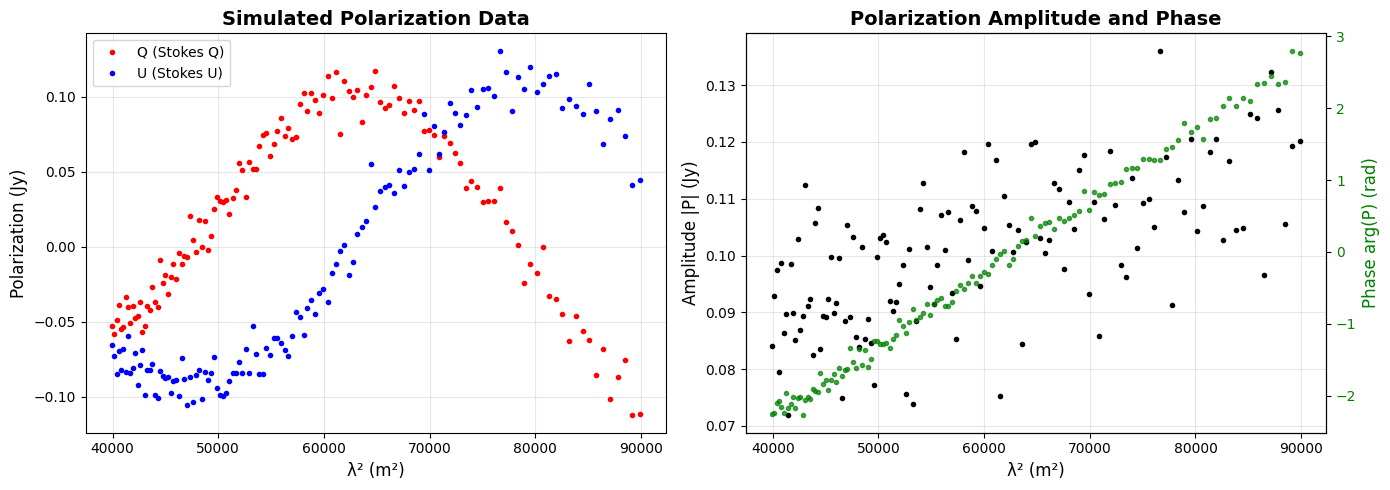

In [13]:
lambda2 = np.asarray(asnumpy(source.lambda2))
data = np.asarray(asnumpy(source.data))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Q and U vs λ²
ax = axes[0]
ax.plot(lambda2 * 1e6, data.real, 'r.', label='Q (Stokes Q)', linewidth=2)
ax.plot(lambda2 * 1e6, data.imag, 'b.', label='U (Stokes U)', linewidth=2)
ax.set_xlabel('λ² (m²)', fontsize=12)
ax.set_ylabel('Polarization (Jy)', fontsize=12)
ax.set_title('Simulated Polarization Data', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot amplitude and phase
ax = axes[1]
amplitude = np.abs(data)
phase = np.angle(data)
ax2 = ax.twinx()
ax.plot(lambda2 * 1e6, amplitude, 'k.', label='|P|', linewidth=2)
ax2.plot(lambda2 * 1e6, phase, 'g.', label='arg(P)', linewidth=2, alpha=0.7)
ax.set_xlabel('λ² (m²)', fontsize=12)
ax.set_ylabel('Amplitude |P| (Jy)', fontsize=12, color='k')
ax2.set_ylabel('Phase arg(P) (rad)', fontsize=12, color='g')
ax.set_title('Polarization Amplitude and Phase', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelcolor='k')
ax2.tick_params(axis='y', labelcolor='g')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Compute Dirty Faraday Depth Spectrum

Calculate the dirty spectrum using the adjoint of the measurement operator.

In [14]:
# Set up Faraday depth grid and measurement operator via pipeline helpers
param = build_parameter(source, oversampling=4.0)
op, _ = build_measurement_operator(source, param, kind="direct")

# Compute dirty spectrum: A^H(data)
fd_dirty = op.dirty_spectrum(source.data)
fd_dirty_np = np.asarray(asnumpy(fd_dirty))

phi = np.asarray(asnumpy(param.phi))

print(f"Faraday depth grid:")
print(f"  Range: [{phi.min():.2f}, {phi.max():.2f}] rad/m²")
print(f"  Number of points: {len(phi)}")
print(f"  Cell size: {param.cellsize:.3f} rad/m²")
print(f"  RMTF FWHM: {param.rmtf_fwhm:.3f} rad/m²")

Faraday depth grid:
  Range: [-4405.50, 4387.15] rad/m²
  Number of points: 480
  Cell size: 18.356 rad/m²
  RMTF FWHM: 69.378 rad/m²


## 4. Visualize the Dirty Spectrum

Plot the dirty Faraday depth spectrum and verify the peak location.

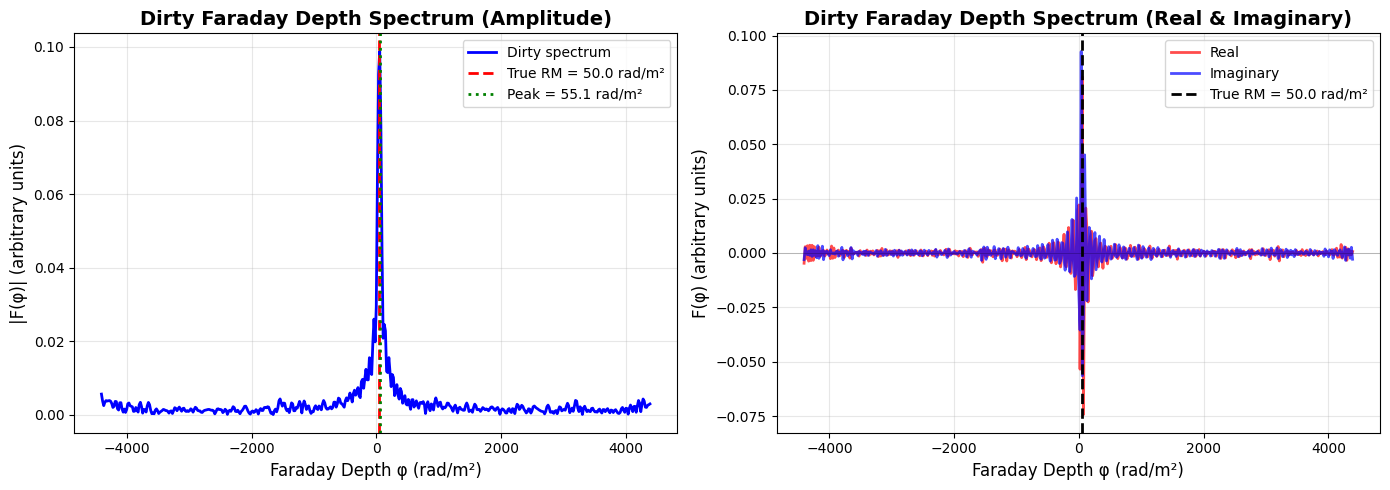


Peak location verification:
  True RM: 50.00 rad/m²
  Peak RM: 55.07 rad/m²
  Error: 5.07 rad/m²
  RMTF FWHM: 69.38 rad/m²
  ✓ Peak is within RMTF FWHM (good!)


In [15]:
# Find peak location
peak_idx = np.argmax(np.abs(fd_dirty_np))
peak_phi = phi[peak_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot amplitude
ax = axes[0]
ax.plot(phi, np.abs(fd_dirty_np), 'b-', linewidth=2, label='Dirty spectrum')
ax.axvline(source.phi_gal, color='r', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f} rad/m²')
ax.axvline(peak_phi, color='g', linestyle=':', linewidth=2, label=f'Peak = {peak_phi:.1f} rad/m²')
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)| (arbitrary units)', fontsize=12)
ax.set_title('Dirty Faraday Depth Spectrum (Amplitude)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot real and imaginary parts
ax = axes[1]
ax.plot(phi, fd_dirty_np.real, 'r-', linewidth=2, label='Real', alpha=0.7)
ax.plot(phi, fd_dirty_np.imag, 'b-', linewidth=2, label='Imaginary', alpha=0.7)
ax.axvline(source.phi_gal, color='k', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f} rad/m²')
ax.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('F(φ) (arbitrary units)', fontsize=12)
ax.set_title('Dirty Faraday Depth Spectrum (Real & Imaginary)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Verify peak location
rm_error = abs(peak_phi - source.phi_gal)
print(f"\nPeak location verification:")
print(f"  True RM: {source.phi_gal:.2f} rad/m²")
print(f"  Peak RM: {peak_phi:.2f} rad/m²")
print(f"  Error: {rm_error:.2f} rad/m²")
print(f"  RMTF FWHM: {param.rmtf_fwhm:.2f} rad/m²")
if rm_error < param.rmtf_fwhm:
    print(f"  ✓ Peak is within RMTF FWHM (good!)")
else:
    print(f"  ⚠ Peak error exceeds RMTF FWHM")

## Summary

This notebook demonstrated:
- Creating a simulated Faraday-thin source
- Computing the dirty Faraday depth spectrum using DirectFourier1D
- Visualizing the results and verifying peak location

The dirty spectrum shows the Faraday depth structure convolved with the Rotation Measure Transfer Function (RMTF). For point sources, the peak should align with the true Faraday depth.